In [2]:
import numpy as np
import pandas as pd
import matplotlib . pyplot as plt
import statsmodels . api as sm
from ISLP import load_data
from ISLP . models import ( ModelSpec as MS, summarize )
from sklearn . model_selection import train_test_split
from sklearn . linear_model import LinearRegression
from sklearn . metrics import mean_squared_error

In [3]:
Hitters = load_data('Hitters')
Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [4]:
Hitters = load_data('Hitters')
np.isnan(Hitters['Salary']).sum()

np.int64(59)

In [5]:
Hitters = Hitters[Hitters['Salary'] > 0]
np.isnan(Hitters['Salary']).sum()

np.int64(0)

In [6]:
X = MS(Hitters.drop(columns='Salary')).fit_transform(Hitters)
Y = Hitters.Salary
X_train, X_test, y_train, y_test = train_test_split(X, Hitters.Salary, test_size=0.3, random_state=0)
model = sm.OLS(y_train, X_train)
results = model.fit() 
summarize(results)

,coef,std err,t,P>|t|
intercept,167.4209,108.190,1.547,0.124
AtBat,-1.8357,0.767,-2.393,0.018
Hits,6.0182,3.032,1.985,0.049
HmRun,6.9428,8.077,0.860,0.391
Runs,-2.2085,3.604,-0.613,0.541
RBI,0.1478,3.456,0.043,0.966
Walks,6.3166,2.293,2.755,0.007
Years,-3.2321,14.941,-0.216,0.829
CAtBat,-0.2448,0.168,-1.456,0.147
CHits,0.9410,0.858,1.096,0.275


In [7]:

from ISLP import load_data
from sklearn.preprocessing import StandardScaler

from ISLP.models import (ModelSpec as MS)
BrainCancer = load_data('BrainCancer')

BrainCancer.head()

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
3,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
4,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30


In [10]:
X = MS(BrainCancer.columns.drop(['time'])).fit_transform(BrainCancer)
scaler= StandardScaler(with_mean=True, with_std=True, copy=True)
scaler.fit(X)
X_std = scaler.transform(X)

In [11]:
X_train , X_test , y_train , y_test = train_test_split (np . asarray ( X_std ),
BrainCancer.time , test_size =20, random_state =0)

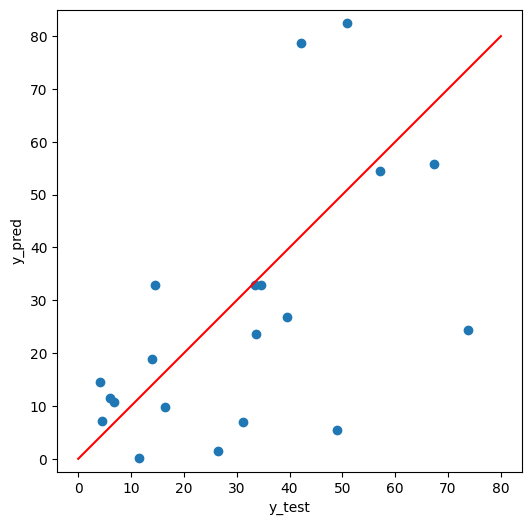

In [12]:
from sklearn.neighbors import KNeighborsRegressor

knn1 = KNeighborsRegressor(n_neighbors=1)
y_pred = knn1.fit(X_train, y_train).predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.plot([0, 80], [0, 80], color='red')
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.axis("equal")
plt.show()